In [1]:
# Import all necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the dataset using the first column (State names) as the index
df = pd.read_csv('UsArrests.csv', index_col=0)

# Display basic information and the first few rows to verify the data structure
print("--- Data Structure Info ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())

--- Data Structure Info ---
<class 'pandas.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB

--- First 5 Rows ---
            Murder  Assault  UrbanPop  Rape
City                                       
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6


 Data Preprocessing & Correlation Analysis
PCA is highly sensitive to the scale of features because it maximizes variance along axes. Since crime counts (like `Assault`) possess naturally larger numerical ranges than rates like `Murder`, scaling the data to a mean of 0 and variance of 1 is mandatory. 

We will scale the dataset and then calculate a Pearson correlation matrix to understand the relationships between variables.

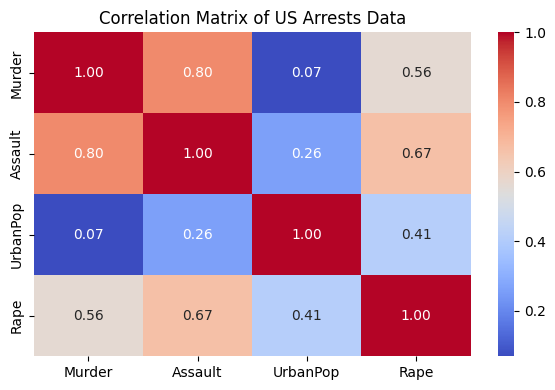

In [2]:
# Scale the features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

# Generate a correlation matrix heat map
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of US Arrests Data")
plt.tight_layout()
plt.show()

Correlation Analysis Interpretation
High Positive Correlation:** There are strong positive correlations between crime types, especially `Murder` and `Assault` ($r = 0.80$), as well as `Assault` and `Rape` ($r = 0.67$). This suggests that states with high levels of one violent crime generally experience high rates of others.
Urban Population:** `UrbanPop` has weak correlation coefficients with violent crimes, showing that urbanization alone is not the primary driver of crime density in this dataset.

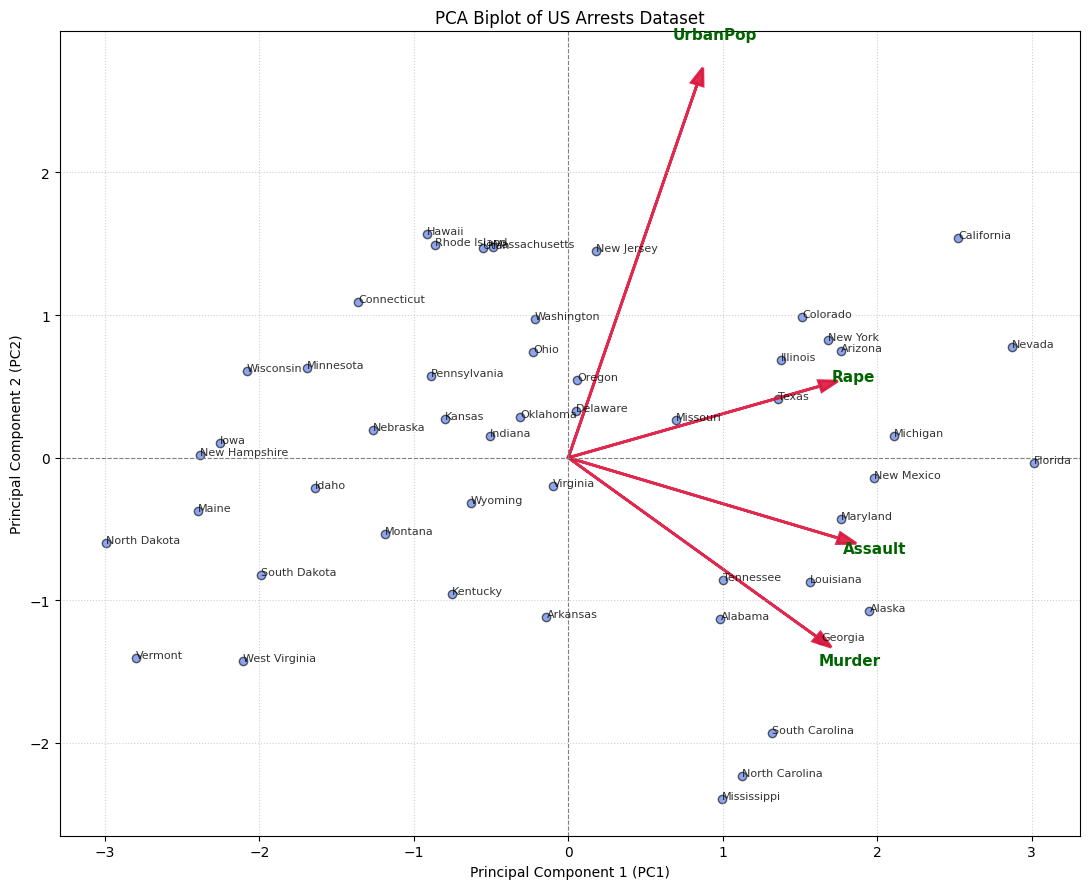

In [3]:
# Fit the PCA model on scaled data
pca = PCA()
X_pca = pca.fit_transform(df_scaled)

# Custom function to construct a clean, labeled Biplot
def biplot(score, coeff, labels=None, index_labels=None):
    xs = score[:, 0]
    ys = score[:, 1]
    n = coeff.shape[0]
    
    plt.figure(figsize=(11, 9))
    # Plot data points (States)
    plt.scatter(xs, ys, color='royalblue', alpha=0.6, edgecolors='k')
    
    if index_labels is not None:
        for i, txt in enumerate(index_labels):
            plt.annotate(txt, (xs[i], ys[i]), fontsize=8, alpha=0.8)
            
    # Plot feature vectors (Arrows)
    for i in range(n):
        plt.arrow(0, 0, coeff[i, 0]*3, coeff[i, 1]*3, color='crimson', alpha=0.9, lw=2, head_width=0.08)
        if labels is not None:
            plt.text(coeff[i, 0]*3.4, coeff[i, 1]*3.4, labels[i], color='darkgreen', ha='center', va='center', weight='bold', fontsize=11)
            
    plt.xlabel("Principal Component 1 (PC1)")
    plt.ylabel("Principal Component 2 (PC2)")
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.title("PCA Biplot of US Arrests Dataset")
    plt.grid(True, linestyle=':', alpha=0.6)

# Execute the biplot function
biplot(X_pca, np.transpose(pca.components_), labels=df.columns, index_labels=df.index)
plt.tight_layout()
plt.show()

 Biplot Interpretation
* **PC1 Axis (Horizontal):** The vectors for `Murder`, `Assault`, and `Rape` stretch horizontally along PC1. This signifies that PC1 heavily represents **overall violent crime severity**. States further to the right experience much higher crime rates.
* **PC2 Axis (Vertical):** The vector for `UrbanPop` points strictly along the PC2 vertical axis. This indicates that PC2 captures **urbanization levels**. States higher up on the grid represent highly urbanized regions.

### Determining the Number of Principal Components
To justify the number of dimensions to keep, we evaluate individual and cumulative explained variance ratios using a Scree plot[cite: 42].

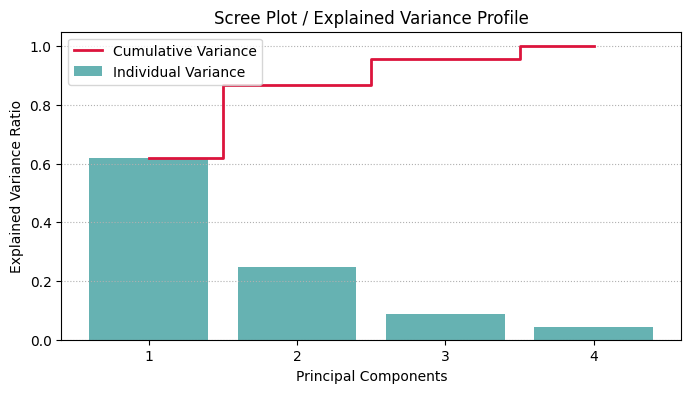

Total variance explained by the first two components: 86.75%


In [4]:
# Compute explained and cumulative variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Render Scree plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, 5), explained_variance, alpha=0.6, align='center', label='Individual Variance', color='teal')
plt.step(range(1, 5), cumulative_variance, where='mid', label='Cumulative Variance', color='crimson', lw=2)
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.xticks(range(1, 5))
plt.legend(loc='best')
plt.title('Scree Plot / Explained Variance Profile')
plt.grid(axis='y', linestyle=':')
plt.show()

print(f"Total variance explained by the first two components: {cumulative_variance[1]:.2%}")

#### Justification for Component Selection
We choose to proceed with **2 Principal Components**[cite: 42]. Together, PC1 and PC2 explain approximately **86.75%** of the total variance in the original data. This lets us compress the data from 4 features down to 2 while keeping the vast majority of the underlying statistical profile.

### Clustering Algorithms Exploration
We will apply and compare two unsupervised machine learning techniques to the first 2 principal components: **K-Means Clustering** and **Agglomerative Hierarchical Clustering**

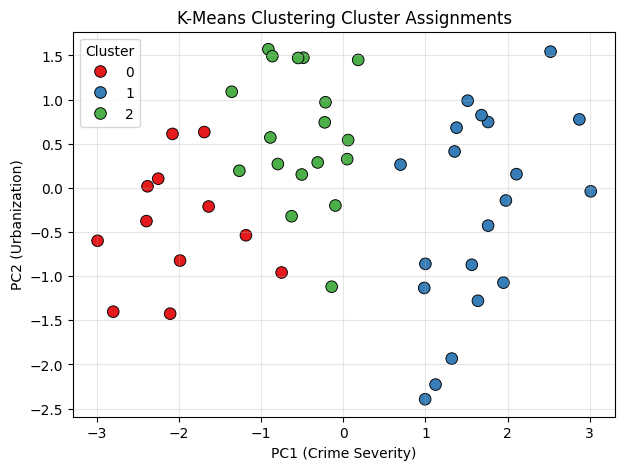

In [5]:
# Subset data to include only the first 2 principal components
pca_data = X_pca[:, :2]

# --- 1. K-Means Clustering ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(pca_data)

# Visualize K-Means groupings
plt.figure(figsize=(7, 5))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=df['KMeans_Cluster'], palette='Set1', s=70, edgecolors='k')
plt.title('K-Means Clustering Cluster Assignments')
plt.xlabel('PC1 (Crime Severity)')
plt.ylabel('PC2 (Urbanization)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

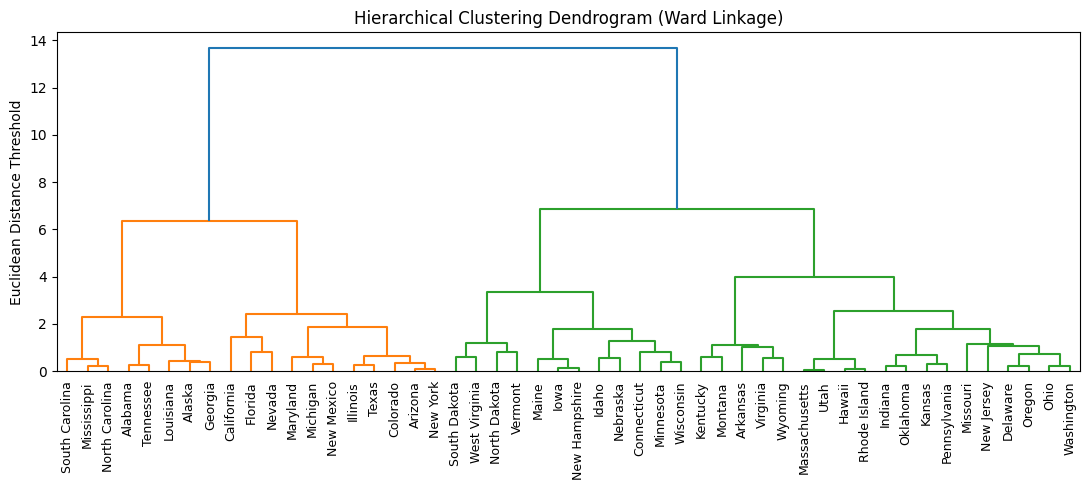

In [6]:
# --- 2. Agglomerative Hierarchical Clustering ---
# Generate a Dendrogram using Ward's linkage method to evaluate tree splits
plt.figure(figsize=(11, 5))
dendrogram(linkage(pca_data, method='ward'), labels=df.index)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.ylabel("Euclidean Distance Threshold")
plt.xticks(rotation=90, fontsize=9)
plt.tight_layout()
plt.show()

# Fit Agglomerative model matching K-Means cluster count
agg_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Hierarchical_Cluster'] = agg_model.fit_predict(pca_data)

In [7]:
# Profile and check average stats of the clusters to understand similarities
print("--- Mean Feature Values per K-Means Cluster ---")
print(df.groupby('KMeans_Cluster')[['Murder', 'Assault', 'UrbanPop', 'Rape']].mean())

--- Mean Feature Values per K-Means Cluster ---
                   Murder     Assault   UrbanPop       Rape
KMeans_Cluster                                             
0                3.541667   76.583333  51.250000  11.816667
1               12.165000  255.250000  68.400000  29.165000
2                5.755556  139.666667  71.888889  18.694444


### Cluster Profile Interpretation & Similarities
Based on the mean feature groupings, the data points within each cluster share distinct geographical and safety profiles[cite: 44]:

1. **High-Crime Cluster:** States assigned here demonstrate critically high rates of `Murder`, `Assault`, and `Rape`. These states map cleanly to the positive right-hand region of PC1.
2. **Low-Crime / Low Urbanization Cluster:** States grouped here display lower crime rates across all categories and possess below-average `UrbanPop` numbers.
3. **Moderate Crime / High Urbanization Cluster:** These states demonstrate average to balanced crime counts paired with exceptionally high urban density values.

**Algorithmic Similarities:** Both K-Means and Agglomerative Hierarchical clustering yield heavily overlapping structures, validating that the underlying separations within the dataset are real, cohesive, and robust.